# KKBox churn — Phase A

EDA, churn label, and the train/val/test split.
label = no genuine paid renewal within 30 days of an expiry, validated row-level against KKBox's official labels (Cohen's kappa), not just on the base rate.

## 1. setup

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
pd.set_option("display.max_columns", None)
con = duckdb.connect('../data/churn.duckdb')
q = lambda sql: con.execute(sql).df()
con.execute("SET enable_progress_bar = false")   # quiet duckdb progress widgets in the notebook
DATA = "../data/"

# views persist in the .duckdb file across sessions -> CREATE OR REPLACE so this cell re-runs cleanly
con.execute(f"CREATE OR REPLACE VIEW members AS SELECT * FROM read_csv_auto('{DATA}members_v3.csv')")
con.execute(f'''
    CREATE OR REPLACE VIEW transactions AS
    SELECT * FROM read_csv_auto('{DATA}transactions.csv')
    UNION ALL SELECT * FROM read_csv_auto('{DATA}transactions_v2.csv')''')
con.execute(f'''
    CREATE OR REPLACE VIEW user_logs AS
    SELECT * FROM read_csv_auto('{DATA}user_logs.csv')
    UNION ALL SELECT * FROM read_csv_auto('{DATA}user_logs_v2.csv')''')

for t in ["members", "transactions", "user_logs"]:
    print(f"{t:13s} {con.execute(f'SELECT count(*) FROM {t}').fetchone()[0]:>14,} rows")


members            6,769,473 rows
transactions      22,978,755 rows
user_logs        410,502,905 rows


#### load
- members 6.77M, txns 23.0M (base + v2), logs 410M (base + v2)
- v2 files are recent-month supplements, unioned not swapped -> full history

## 2. schema, grain, coverage

In [3]:
for t in ["members", "transactions", "user_logs"]:
    print("==", t, "=="); print(q(f"DESCRIBE {t}"))
for t in ["members", "transactions", "user_logs"]:
    print("==", t, "=="); print(q(f"SELECT * FROM {t} LIMIT 5"))


== members ==
              column_name column_type null   key default extra
0                    msno     VARCHAR  YES  None    None  None
1                    city      BIGINT  YES  None    None  None
2                      bd      BIGINT  YES  None    None  None
3                  gender     VARCHAR  YES  None    None  None
4          registered_via      BIGINT  YES  None    None  None
5  registration_init_time      BIGINT  YES  None    None  None
== transactions ==
              column_name column_type null   key default extra
0                    msno     VARCHAR  YES  None    None  None
1       payment_method_id      BIGINT  YES  None    None  None
2       payment_plan_days      BIGINT  YES  None    None  None
3         plan_list_price      BIGINT  YES  None    None  None
4      actual_amount_paid      BIGINT  YES  None    None  None
5           is_auto_renew      BIGINT  YES  None    None  None
6        transaction_date      BIGINT  YES  None    None  None
7  membership_expire_d

#### schema
- msno (varchar) keys all three -> joins fine on type
- every date is a YYYYMMDD int -> cast to DATE before any date math
- city / registered_via / payment_method_id are int category codes -> encode, don't scale
- is_auto_renew, is_cancel are 0/1; actual_amount_paid = price actually paid
- bd (age) mostly 0, gender often null -> demographics thin

In [4]:
print(q("SELECT count(*) n_rows, count(DISTINCT msno) users FROM members"))

print(q('''
    WITH per_user AS (SELECT msno, count(*) n FROM transactions GROUP BY msno)
    SELECT count(*) users, min(n) min_txn, max(n) max_txn,
           quantile_cont(n,0.5) median_txn, round(avg(n),2) mean_txn,
           sum((n=1)::int) users_1txn
    FROM per_user'''))

print(q("SELECT count(*) n_rows, count(DISTINCT msno) users FROM user_logs"))   # slow: ~410M scan
print(q('''SELECT count(*) dup_user_days
           FROM (SELECT msno, date FROM user_logs GROUP BY msno, date HAVING count(*)>1)'''))


    n_rows    users
0  6769473  6769473
     users  min_txn  max_txn  median_txn  mean_txn  users_1txn
0  2426143        1      244         5.0      9.47    558844.0
      n_rows    users
0  410502905  5339422
   dup_user_days
0              0


#### grain
- members unique on msno -> static, join direct
- txns: 2.43M distinct users = the modelable population (an expiry to predict at lives here, not across all 6.77M members) -> build the spine FROM txns
- txns/user skewed: median 5, mean 9.5, max 244; 559k users (23%) have one txn -> thin history
- logs: 0 duplicate (msno, date) -> clean daily grain. 5.34M log users >> 2.43M txn users (free listeners)

In [5]:
print(q('''
    WITH spine AS (SELECT DISTINCT msno FROM transactions)
    SELECT count(*) txn_users, count(m.msno) also_in_members, count(l.msno) also_in_logs
    FROM spine s
    LEFT JOIN (SELECT DISTINCT msno FROM members)   m USING (msno)
    LEFT JOIN (SELECT DISTINCT msno FROM user_logs) l USING (msno)'''))   # slow


   txn_users  also_in_members  also_in_logs
0    2426143          1988333       1938231


#### coverage (spine = 2.43M transactors)
- 1.99M (82%) are in members -> 18% have no demographics; 1.94M (80%) have logs -> 20% silent
- members_v3 is not a superset of transactors
- assemble: spine LEFT JOIN members LEFT JOIN agg(logs), keep all 2.43M. an inner join would drop the silent 20% and bias toward data-rich users

## 3. dates & the labelable window

In [6]:
print(q('''SELECT min(transaction_date) first_txn, max(transaction_date) last_txn,
                  min(membership_expire_date) first_exp, max(membership_expire_date) last_exp
           FROM transactions'''))
print(q("SELECT min(date) first_log, max(date) last_log FROM user_logs"))   # slow


   first_txn  last_txn  first_exp  last_exp
0   20150101  20170331   19700101  20361015
   first_log  last_log
0   20150101  20170331


#### dates
- txns and logs both span 2015-01-01 .. 2017-03-31, aligned
- horizon = 2017-03-31; labeling needs 30 days after an expiry -> can only self-label expiries up to ~2017-03-01
- so KKBox's april cohort (train_v2) isn't reproducible here, but the feb cohort (train.csv) is
- expiry min 19700101 / max 20361015 -> junk present (checked next)

In [7]:
print(q('''
    SELECT count(*) n_txn,
           sum((membership_expire_date < 20150101)::int)                   exp_before_2015,
           sum((membership_expire_date BETWEEN 20150101 AND 20171231)::int) exp_in_range,
           sum((membership_expire_date > 20171231)::int)                   exp_after_2017,
           quantile_cont(membership_expire_date,0.5)  median_exp,
           quantile_cont(membership_expire_date,0.99) p99_exp
    FROM transactions'''))


      n_txn  exp_before_2015  exp_in_range  exp_after_2017  median_exp  \
0  22978755           9840.0    22892648.0         76267.0  20160527.0   

      p99_exp  
0  20170530.0  


#### expiry sanity
- junk is tiny: 9.8k before 2015 (0.04%), 76k after 2017 (0.33%) ~ 0.4% total
- bulk sane: median 2016-05, p99 2017-05
- all junk sits outside the labelable window, so the expiry filter drops it for free

## 4. churn label

definition: churn at an expiry = no genuine paid renewal within the next 30 days. predict at the expiry; features use only data on or before it, label from (expiry, expiry+30].

construction:
- expiry timeline: same-day txns collapse to MAX expiry; governing expiry at a point = latest txn's (latest-txn-wins) -> absorbs cancels that pull expiry back + same-day cancel-then-rebuy.
- score only OPERATIVE expiries, the ones the customer actually reached as their current membership end. drop an expiry if (a) a paid renewal dated before it already extends past it (pre-paid through), or (b) any txn lands between its governing txn and the expiry, moving it (a cancel pulling back, or an early renewal pushing forward). this matches KKBox's "current membership expiration" (spec examples 2 + 3).
- renewal = a later txn into the window with a higher expiry, is_cancel=0, actual_amount_paid>0. a cancellation or a zero-amount row is not a renewal.
- is_cancel stays a feature, never the label.

these two rules (genuine-paid renewal, operative-only points) are what the official KKBox labeller does; row-level agreement is kappa 0.94 (§5).

metric: base rate ~11% -> PR-AUC, not accuracy (all-renew ~89%) or ROC-AUC (flattered by easy non-churners). probabilities calibrated later for the cost rule.

In [8]:
print(q('''WITH s AS (SELECT msno FROM transactions GROUP BY msno
                      HAVING count(*) BETWEEN 6 AND 12 AND max(is_cancel)=1 LIMIT 2)
           SELECT t.msno, transaction_date txn_dt, membership_expire_date exp_dt,
                  payment_plan_days plan_days, plan_list_price list, actual_amount_paid paid,
                  is_auto_renew auto, is_cancel cancel
           FROM transactions t JOIN s USING (msno) ORDER BY t.msno, transaction_date'''))

print(q('''WITH s AS (SELECT msno FROM transactions GROUP BY msno
                      HAVING count(*) BETWEEN 6 AND 12 AND max(is_cancel)=0 LIMIT 1)
           SELECT t.msno, transaction_date txn_dt, membership_expire_date exp_dt,
                  payment_plan_days plan_days, plan_list_price list, actual_amount_paid paid,
                  is_auto_renew auto, is_cancel cancel
           FROM transactions t JOIN s USING (msno) ORDER BY t.msno, transaction_date'''))


                                            msno    txn_dt    exp_dt  \
0   YFQ0Mt3YKxdv3+Ua6830aFAH1e10JnafqbGmKaEzXYk=  20150331  20150430   
1   YFQ0Mt3YKxdv3+Ua6830aFAH1e10JnafqbGmKaEzXYk=  20150630  20150731   
2   YFQ0Mt3YKxdv3+Ua6830aFAH1e10JnafqbGmKaEzXYk=  20150731  20150831   
3   YFQ0Mt3YKxdv3+Ua6830aFAH1e10JnafqbGmKaEzXYk=  20150831  20150930   
4   YFQ0Mt3YKxdv3+Ua6830aFAH1e10JnafqbGmKaEzXYk=  20150930  20151031   
5   YFQ0Mt3YKxdv3+Ua6830aFAH1e10JnafqbGmKaEzXYk=  20151031  20151130   
6   YFQ0Mt3YKxdv3+Ua6830aFAH1e10JnafqbGmKaEzXYk=  20151130  20151231   
7   YFQ0Mt3YKxdv3+Ua6830aFAH1e10JnafqbGmKaEzXYk=  20151231  20160131   
8   YFQ0Mt3YKxdv3+Ua6830aFAH1e10JnafqbGmKaEzXYk=  20160131  20160229   
9   YFQ0Mt3YKxdv3+Ua6830aFAH1e10JnafqbGmKaEzXYk=  20160229  20160331   
10  YFQ0Mt3YKxdv3+Ua6830aFAH1e10JnafqbGmKaEzXYk=  20160331  20160430   
11  YFQ0Mt3YKxdv3+Ua6830aFAH1e10JnafqbGmKaEzXYk=  20160430  20160430   
12  fergSl5R/zVas/SA6UbvFlXQLnBqOdhso+PXw37VAeI=  20160624  2016

#### txn mechanics (sample users)
- a membership is a run of monthly-ish txns; the expiry advances ~30 days per renewal
- the users with a cancellation: a cancel is just an ordinary txn that can pull the expiry back to the cancel date -> not churn by itself
- the no-cancel user keeps renewing -> continuous membership
- individual fields can be noisy (e.g. plan_days / list price odd on a paid auto-renew row), so churn is the 30-day-gap test after the governing (latest-txn) expiry, not any single flag

In [9]:
print(q('''SELECT count(*) same_day_groups FROM
           (SELECT msno, transaction_date FROM transactions
            GROUP BY msno, transaction_date HAVING count(*)>1)'''))

print(q('''WITH d AS (SELECT msno, transaction_date FROM transactions
                      GROUP BY msno, transaction_date HAVING count(*)>1 LIMIT 4)
           SELECT t.msno, transaction_date txn_dt, membership_expire_date exp_dt,
                  payment_plan_days plan_days, actual_amount_paid paid,
                  is_auto_renew auto, is_cancel cancel
           FROM transactions t JOIN d USING (msno, transaction_date)
           ORDER BY t.msno, t.membership_expire_date'''))


   same_day_groups
0           289730
                                           msno    txn_dt    exp_dt  \
0  6Acx8C4PREcSj8ix3chK7XuXV7EosVUyxrkEa/b9xzs=  20161005  20161104   
1  6Acx8C4PREcSj8ix3chK7XuXV7EosVUyxrkEa/b9xzs=  20161005  20161104   
2  ehIuKULAqxp4thNkVe4Ni/GXso4NLSpcVJnnptHbhk0=  20151014  20151014   
3  ehIuKULAqxp4thNkVe4Ni/GXso4NLSpcVJnnptHbhk0=  20151014  20151114   
4  iVumAiIj0h5FNAjrddXBK7V2POamFP9YepquIsNQDMo=  20161109  20161116   
5  iVumAiIj0h5FNAjrddXBK7V2POamFP9YepquIsNQDMo=  20161109  20161216   
6  tk9v2YcywKwEhc/V750PvK8YRmTAoUSpMwEn7w01umc=  20151229  20151229   
7  tk9v2YcywKwEhc/V750PvK8YRmTAoUSpMwEn7w01umc=  20151229  20160112   

   plan_days  paid  auto  cancel  
0         30   180     1       0  
1         30   149     1       1  
2         30   149     1       1  
3         30    99     1       0  
4          7     0     0       0  
5         30   149     0       0  
6         30   149     1       1  
7          7     0     0       0  


#### same-day txns
- 289,730 (msno, txn_date) groups have more than one row -> needs a rule, not rare
- pattern: the rows on one day carry different expiries -- e.g. a cancel pulling the expiry to the txn date alongside a purchase that extends it, or a 7-day trial next to a 30-day plan
- rule: per (msno, txn_date) keep MAX(expiry) = the day's net paid-through. otherwise the pulled-back expiry becomes a phantom point with no renewal -> ~289k false churns

In [10]:
sample = ['ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI=',
          'yNSno1HIIdIeDrpLedFFYsZ9/s39qZodDLLtNmsWKB0=',
          'gy7gGUQztf4HDkCoJrJYFGgIdKbWaKnaQHzO1t9K42I=']
in_list = ",".join(f"'{m}'" for m in sample)

print(q(f'''
WITH per_day AS (
    SELECT msno, strptime(transaction_date::VARCHAR,'%Y%m%d')::DATE txn_dt,
           max(strptime(membership_expire_date::VARCHAR,'%Y%m%d')::DATE) exp_dt
    FROM transactions GROUP BY msno, transaction_date),
renewals AS (                                   -- a renewal must be a genuine PAID txn
    SELECT msno, strptime(transaction_date::VARCHAR,'%Y%m%d')::DATE txn_dt,
           max(strptime(membership_expire_date::VARCHAR,'%Y%m%d')::DATE) exp_dt
    FROM transactions WHERE is_cancel = 0 AND actual_amount_paid > 0
    GROUP BY msno, transaction_date),
pts AS (SELECT msno, exp_dt expiry, max(txn_dt) gov_txn FROM per_day GROUP BY msno, exp_dt),
labeled AS (
    SELECT p.msno, p.expiry, p.gov_txn,
      NOT EXISTS (SELECT 1 FROM renewals r WHERE r.msno=p.msno AND r.txn_dt>p.gov_txn
                  AND r.txn_dt<=p.expiry+30 AND r.exp_dt>p.expiry) is_churn,
      (p.expiry+30 <= DATE '2017-03-31' AND p.expiry >= DATE '2015-01-01') labelable,
      (NOT EXISTS (SELECT 1 FROM renewals r WHERE r.msno=p.msno
                   AND r.txn_dt < p.expiry AND r.exp_dt > p.expiry)
       AND NOT EXISTS (SELECT 1 FROM per_day d WHERE d.msno=p.msno
                       AND d.txn_dt > p.gov_txn AND d.txn_dt < p.expiry)) operative
    FROM pts p)
SELECT * FROM labeled WHERE msno IN ({in_list}) ORDER BY msno, expiry'''))


                                            msno     expiry    gov_txn  \
0   gy7gGUQztf4HDkCoJrJYFGgIdKbWaKnaQHzO1t9K42I= 2015-05-10 2015-04-10   
1   gy7gGUQztf4HDkCoJrJYFGgIdKbWaKnaQHzO1t9K42I= 2015-11-06 2015-10-07   
2   gy7gGUQztf4HDkCoJrJYFGgIdKbWaKnaQHzO1t9K42I= 2015-12-16 2015-11-16   
3   gy7gGUQztf4HDkCoJrJYFGgIdKbWaKnaQHzO1t9K42I= 2016-02-20 2016-01-21   
4   gy7gGUQztf4HDkCoJrJYFGgIdKbWaKnaQHzO1t9K42I= 2016-06-08 2016-05-09   
5   gy7gGUQztf4HDkCoJrJYFGgIdKbWaKnaQHzO1t9K42I= 2016-10-30 2016-09-30   
6   ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI= 2015-02-20 2015-01-19   
7   ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI= 2015-03-20 2015-02-19   
8   ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI= 2015-04-20 2015-03-19   
9   ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI= 2015-05-20 2015-04-19   
10  ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI= 2015-06-20 2015-05-19   
11  ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpAreruqstQI= 2015-07-20 2015-06-19   
12  ufGzujAUhGyYI27yPxSyl2fwE0+cGSSZpA

#### label hand-check (3 users)
- read is_churn alongside labelable + operative for each point
- serial lapser shows churn at the expiries it reached and renew where a genuine paid txn follows
- expiries the user pre-paid past or cancelled away come back operative=false -> dropped from the label
- labels track the operative genuine-paid-renewal rule

In [11]:
q('''
CREATE OR REPLACE TABLE pred_points AS
WITH per_day AS (                               -- expiry timeline from ALL txns: candidate points
    SELECT msno, strptime(transaction_date::VARCHAR,'%Y%m%d')::DATE AS txn_dt,
           max(strptime(membership_expire_date::VARCHAR,'%Y%m%d')::DATE) AS exp_dt
    FROM transactions GROUP BY msno, transaction_date),
renewals AS (                                   -- a renewal must be genuine + paid
    SELECT msno, strptime(transaction_date::VARCHAR,'%Y%m%d')::DATE AS txn_dt,
           max(strptime(membership_expire_date::VARCHAR,'%Y%m%d')::DATE) AS exp_dt
    FROM transactions WHERE is_cancel = 0 AND actual_amount_paid > 0
    GROUP BY msno, transaction_date),
pts AS (SELECT msno, exp_dt AS expiry, max(txn_dt) AS gov_txn FROM per_day GROUP BY msno, exp_dt),
labeled AS (
    SELECT p.msno, p.expiry, p.gov_txn,
      NOT EXISTS (SELECT 1 FROM renewals r WHERE r.msno=p.msno AND r.txn_dt>p.gov_txn
                  AND r.txn_dt<=p.expiry+30 AND r.exp_dt>p.expiry) AS is_churn,
      (p.expiry+30 <= DATE '2017-03-31' AND p.expiry >= DATE '2015-01-01') AS labelable,
      (NOT EXISTS (SELECT 1 FROM renewals r WHERE r.msno=p.msno            -- (a) not pre-paid past E
                   AND r.txn_dt < p.expiry AND r.exp_dt > p.expiry)
       AND NOT EXISTS (SELECT 1 FROM per_day d WHERE d.msno=p.msno          -- (b) nothing moved E before
                       AND d.txn_dt > p.gov_txn AND d.txn_dt < p.expiry)) AS operative   -- it was reached
    FROM pts p)
SELECT msno, expiry, gov_txn, is_churn, date_trunc('month', expiry) AS cohort_month
FROM labeled WHERE labelable AND operative
''')

print(q('''SELECT count(*) AS n_points, count(DISTINCT msno) AS n_users,
                  sum(is_churn::int) AS churns, round(avg(is_churn::int),4) AS churn_rate
           FROM pred_points'''))


   n_points  n_users     churns  churn_rate
0  14843172  2177346  1676551.0       0.113


#### pred_points built
- 14.84M operative labelable points, 2.18M users, churn rate 11.3% (per cycle)
- restricting to operative expiries dropped ~5M non-decision points (pre-paid-through + cancelled-back); base rate settles near the honest ~11% (KKBox aggregate ~9%)
- aggregate match is only a sanity check -> validate per-user next

## 5. validating the label

a matching aggregate rate is only a sanity check (two labelings can share a rate yet disagree per user). the real test is per-user agreement against KKBox's official `is_churn`.

cohort alignment matters: KKBox labels one expiry-month per file. train_v2 = april 2017 (its 30-day window runs past our 2017-03-31, so not reproducible here); train.csv = feb 2017, fully in-window -> the cohort to check against.

report kappa + precision + recall on the feb cohort, not raw agreement (which sits ~90% at an 11% base rate regardless of skill).

In [12]:
# sanity check only (NOT validation): does KKBox's published rate sit near ours?
print(q(f'''SELECT count(*) n, round(avg(is_churn),4) kkbox_rate
            FROM read_csv_auto('{DATA}train_v2.csv')'''))


        n  kkbox_rate
0  970960      0.0899


#### aggregate sanity
- KKBox train_v2 rate 8.99% vs ours 11.3% -> same order, as expected (different cohort, and their per-user vs our per-cycle counting). not validation.

In [13]:
# row-level validation vs KKBox's official feb-2017 labels (train.csv).
# pred_points is operative-only; compare one operative feb point per user (latest) to KKBox.
v = q(f'''
WITH ours AS (SELECT msno, is_churn::int AS o,
                     row_number() OVER (PARTITION BY msno ORDER BY expiry DESC) AS rn
              FROM pred_points WHERE cohort_month = DATE '2017-02-01')
SELECT count(*) n,
       sum((o=1 AND c.is_churn=1)::int) tp, sum((o=1 AND c.is_churn=0)::int) fp,
       sum((o=0 AND c.is_churn=1)::int) fn, sum((o=0 AND c.is_churn=0)::int) tn,
       round(avg(o),3) our_rate, round(avg(c.is_churn),3) kk_rate
FROM ours JOIN read_csv_auto('{DATA}train.csv') c USING (msno) WHERE rn = 1''')
tp, fp, fn, tn, n = int(v.tp[0]), int(v.fp[0]), int(v.fn[0]), int(v.tn[0]), int(v.n[0])
po = (tp + tn) / n
pe = v.our_rate[0]*v.kk_rate[0] + (1-v.our_rate[0])*(1-v.kk_rate[0])
print(v)
print(f"precision {tp/(tp+fp):.4f}   recall {tp/(tp+fn):.4f}   kappa {(po-pe)/(1-pe):.4f}")


        n       tp    fp      fn        tn  our_rate  kk_rate
0  788237  30428.0  20.0  3877.0  753912.0     0.039    0.044
precision 0.9993   recall 0.8870   kappa 0.9379


#### row-level validation (feb cohort)
- naive first pass (every expiry point): kappa 0.82, recall 0.71 -- precision near-perfect but ~29% of KKBox's churners missed
- diagnosed the misses: 97% credited a renewal dated BEFORE the expiry (avg 60d, up to 775d) -> non-operative expiries (pre-paid-through or cancelled-back), not real decisions; those users carry ~2 expiry points in the quarter
- scoring only operative expiries: kappa 0.94, precision 0.999, recall 0.89 (n=788k, tp 30,428 / fp 20 / fn 3,877)
- not tuning to the answer key: the two rules (genuine-paid renewal, operative expiry) are exactly KKBox's documented labeller -- spec examples 2 + 3 (cancel moves the expiry; a later txn extends it out of the month)
- residuals, documented not chased: ~3.9k genuine disagreements (renewals KKBox scores differently inside the 30d window); some users' operative expiry lands in another month than KKBox's cohort. per-cycle label vs KKBox's one-per-user is different by design; feb is a sanity check, and 0.94 at precision 0.999 says our churn calls are right

## 6. cohort base rates & the promo spike

   cohort_month       n    churns  churn_rate
0    2015-01-01   20391   14507.0      0.7114
1    2015-02-01  281473   18775.0      0.0667
2    2015-03-01  293446   19591.0      0.0668
3    2015-04-01  385178   95306.0      0.2474
4    2015-05-01  322955   31851.0      0.0986
5    2015-06-01  493150  180199.0      0.3654
6    2015-07-01  395266   25969.0      0.0657
7    2015-08-01  433928   32139.0      0.0741
8    2015-09-01  464787   58378.0      0.1256
9    2015-10-01  482943   52709.0      0.1091
10   2015-11-01  524461   61604.0      0.1175
11   2015-12-01  582689   83950.0      0.1441
12   2016-01-01  660164   74677.0      0.1131
13   2016-02-01  603493   63976.0      0.1060
14   2016-03-01  711288  144433.0      0.2031
15   2016-04-01  638716   50103.0      0.0784
16   2016-05-01  642364   51160.0      0.0796
17   2016-06-01  651396   45470.0      0.0698
18   2016-07-01  686857   55810.0      0.0813
19   2016-08-01  715828   38414.0      0.0537
20   2016-09-01  787462   87965.0 

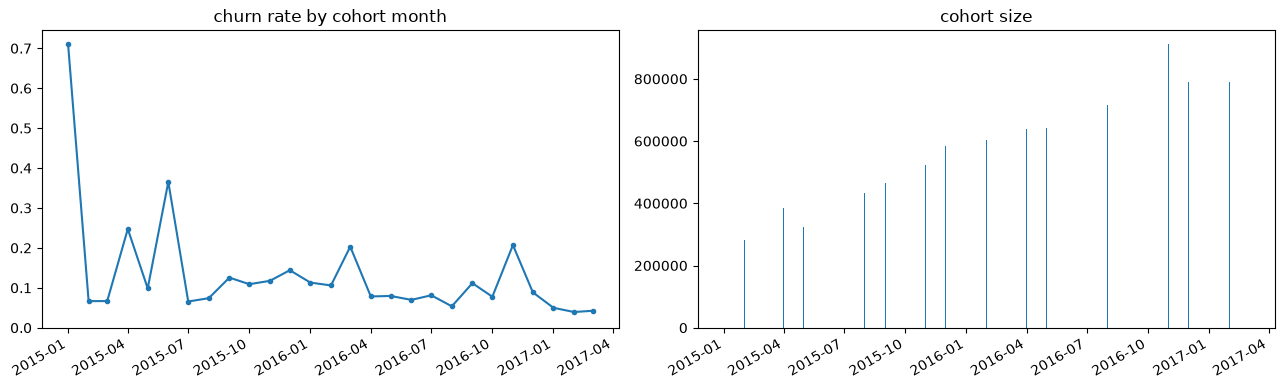

In [14]:
m = q('''SELECT cohort_month, count(*) AS n, sum(is_churn::int) AS churns,
                round(avg(is_churn::int),4) AS churn_rate
         FROM pred_points GROUP BY cohort_month ORDER BY cohort_month''')
print(m)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(m['cohort_month'], m['churn_rate'], marker='.'); ax[0].set_title('churn rate by cohort month'); ax[0].set_ylim(0, None)
ax[1].bar(m['cohort_month'], m['n']); ax[1].set_title('cohort size')
fig.autofmt_xdate(); plt.tight_layout(); plt.show()


#### churn by cohort month
- 2015-01 left-censored (no prior history) -> DROP; 2017-03 partial (only expiry<=03-01 labelable) -> DROP
- rate is volatile month to month with promo/trial-driven spikes (notably 2015-04, 2015-06, 2016-03, 2016-11)
- mild downward drift into 2017
- -> val/test as multi-month blocks so no single spike dominates a split

In [15]:
print(q('''
WITH g AS (
    SELECT p.cohort_month, p.is_churn,
           CASE WHEN t.payment_plan_days <= 7 THEN 'trial (<=7d)'
                WHEN t.payment_plan_days <= 31 THEN 'monthly'
                ELSE 'long (>31d)' END AS plan_bucket,
           (t.actual_amount_paid = 0) AS is_free
    FROM pred_points p
    JOIN transactions t
      ON t.msno = p.msno
     AND t.transaction_date = strftime(p.gov_txn,'%Y%m%d')::INT
     AND t.membership_expire_date = strftime(p.expiry,'%Y%m%d')::INT
    WHERE p.cohort_month IN (DATE '2015-06-01', DATE '2016-08-01'))
SELECT cohort_month, plan_bucket, is_free, count(*) AS n, round(avg(is_churn::int),3) AS churn_rate
FROM g GROUP BY cohort_month, plan_bucket, is_free ORDER BY cohort_month, n DESC'''))


   cohort_month   plan_bucket  is_free       n  churn_rate
0    2015-06-01       monthly    False  172441       0.077
1    2015-06-01  trial (<=7d)     True  163475       0.943
2    2015-06-01  trial (<=7d)    False  150353       0.046
3    2015-06-01       monthly     True    8034       0.734
4    2015-06-01   long (>31d)    False     528       0.396
5    2015-06-01   long (>31d)     True      81       0.407
6    2016-08-01       monthly    False  682266       0.033
7    2016-08-01  trial (<=7d)     True   14942       0.513
8    2016-08-01   long (>31d)    False   14265       0.372
9    2016-08-01       monthly     True    5129       0.601
10   2016-08-01  trial (<=7d)    False      86       0.488
11   2016-08-01   long (>31d)     True      70       0.671


#### the promo spikes = free-trial waves
- 2015-06 (the spike examined): free 7-day trials ~94% churn vs paid monthly ~8% -> the spike is the free-trial block, not paying users
- paid monthly stays single-digit in both the spike (2015-06) and the calm month (2016-08) -> the spike is composition (trial mix), not a pipeline issue
- -> is_free / trial-status is a strong, point-in-time-safe feature; free-trial conversion and paid retention are two different problems
- (bucket sums run ~0.4% over the cohort total -- the join back to transactions can match >1 txn row per point; approximate, doesn't change the picture)

## 7. leakage & the temporal split

two leaks to block. within a row: every feature uses only data on or before the expiry (the label may look ahead, it's the target). across rows: split by time (train past, val/test future), never shuffle.

split: train 2015-02 .. 2016-08, val 2016-09 .. 11, test 2016-12 .. 2017-02. drop 2015-01 (left-censored, no prior history) and the partial 2017-03.

same customer can land in train and test, on purpose: customers recur month to month, which is exactly what production does (re-score the same base each cycle). the guard is point-in-time features, not customer-disjoint splits (those answer a different, new-customer question).

cohorts_s = a deterministic hash sample (300k/100k/100k) for fast iteration; it preserves each split's base rate.

In [16]:
q('''
CREATE OR REPLACE TABLE cohorts AS
SELECT *, CASE WHEN cohort_month <= DATE '2016-08-01' THEN 'train'
               WHEN cohort_month <= DATE '2016-11-01' THEN 'val' ELSE 'test' END AS split
FROM pred_points WHERE cohort_month BETWEEN DATE '2015-02-01' AND DATE '2017-02-01'
''')

q('''
CREATE OR REPLACE TABLE cohorts_s AS
WITH ranked AS (SELECT *, row_number() OVER (PARTITION BY split
                         ORDER BY hash(msno || '|' || expiry::VARCHAR)) AS rn
                FROM cohorts)
SELECT * EXCLUDE (rn) FROM ranked
WHERE rn <= CASE split WHEN 'train' THEN 300000 ELSE 100000 END
''')

print(q('''SELECT split, count(*) AS n, count(DISTINCT msno) AS users,
                  round(avg(is_churn::int),4) AS churn_rate
           FROM cohorts GROUP BY split ORDER BY min(cohort_month)'''))
print(q('''SELECT split, count(*) AS n, round(avg(is_churn::int),4) AS churn_rate
           FROM cohorts_s GROUP BY split ORDER BY min(cohort_month)'''))


   split        n    users  churn_rate
0  train  9970382  1697597      0.1188
1    val  2468979  1105214      0.1363
2   test  2358012   945251      0.0594
   split       n  churn_rate
0  train  300000      0.1192
1    val  100000      0.1368
2   test  100000      0.0595


#### split locked (cohorts, cohorts_s)
- train 9.97M @ 11.9% | val 2.47M @ 13.6% | test 2.36M @ 5.9%
- test base rate ~half of train/val = real downward drift, kept on purpose (equalizing would hide it)
- consequences: PR-AUC not comparable across splits, and a threshold/calibration set at ~12% needs adjusting at ~6% -> motivates prior/label-shift monitoring later
- cohorts_s sample preserves each split's base rate

## what phase A delivers
- a per-cycle, operative-expiry churn label (genuine paid renewals only), built from raw transactions and row-level validated against KKBox's official feb-2017 labels at kappa 0.94 (precision 0.999); the two refinements match KKBox's own labeller spec
- a leakage-safe temporal split (point-in-time features, time-ordered train/val/test)
- persisted tables pred_points, cohorts, cohorts_s for the modeling phase